# 🍽️ Limpieza y Análisis de Ventas — TaquerIA 2023

**Objetivo:** Limpiar un dataset de ventas exportado en crudo y responder 5 preguntas de negocio con datos y gráficas.

**Dataset:** 8,200 registros de ventas diarias por sucursal con 14 columnas — incluyendo fechas en múltiples formatos, valores nulos, duplicados, outliers y texto inconsistente.

---

### Columnas del dataset

| Columna | Descripción | Tipo esperado |
|---|---|---|
| `FECHA` | Fecha de la venta | datetime |
| `ID_TICKET` | Identificador único del ticket | string |
| `SUCURSAL` | Nombre de la sucursal | category |
| `ZONA` | Zona geográfica de la sucursal | category |
| `TURNO` | Turno del día | category |
| `CATEGORIA_PRODUCTO` | Tipo de producto vendido | category |
| `PRODUCTO` | Nombre del producto | string |
| `CANTIDAD` | Unidades vendidas en el ticket | int |
| `PRECIO_UNITARIO` | Precio de venta por unidad | float |
| `DESCUENTO_PCT` | Descuento aplicado (0–100) | float |
| `METODO_PAGO` | Forma de pago | category |
| `TIPO_CLIENTE` | Si es cliente nuevo o recurrente | category |
| `CALIFICACION` | Calificación del servicio (1–5) | float |
| `TIEMPO_ESPERA_MIN` | Minutos que esperó el cliente | int |

---

### Preguntas a responder

1. ¿Cuál sucursal genera más ingresos y cuál menos?
2. ¿En qué meses vendemos más y en qué meses caemos?
3. ¿Qué turno es más rentable? ¿Es consistente entre zonas?
4. ¿La calificación del servicio afecta cuánto gasta el cliente?
5. ¿Qué categoría de producto tiene el margen más alto?

---

**Estructura del notebook:**
```
PARTE 1 — LIMPIEZA     → Tareas 1 a 9
PARTE 2 — ANÁLISIS     → Preguntas 1 a 5 (con gráficas)
PARTE 3 — CONCLUSIONES → Resumen ejecutivo
```

---
# SECCIÓN 0 — Preparación

In [ ]:
# Librerías principales para análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Opciones de display para ver columnas completas y evitar notación científica
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 20)

# Estilo global para todas las gráficas
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('✅ Librerías listas')

✅ Librerías listas


In [ ]:
# Generación del dataset sintético con problemas de calidad intencionales:
# fechas en 4 formatos distintos, nulos, duplicados, outliers y texto inconsistente
import random
from datetime import date, timedelta

random.seed(42)
np.random.seed(42)

n = 8200
sucursales = ['Polanco', 'Tlalpan', 'Santa Fe', 'Centro Histórico', 'Coyoacán', 'Xochimilco']
zonas = {'Polanco': 'Norte', 'Tlalpan': 'Sur', 'Santa Fe': 'Poniente',
         'Centro Histórico': 'Centro', 'Coyoacán': 'Sur', 'Xochimilco': 'Sur'}
turnos_sucios = ['Mañana', 'mañana', 'MAÑANA', 'Tarde', 'tarde', 'TARDE', 'Noche', 'noche', 'NOCHE', None]
categorias = ['Tacos', 'Bebidas', 'Combos', 'Extras', 'Postres']
productos = {
    'Tacos': ['Taco al Pastor', 'Taco de Suadero', 'Taco Vegetariano', 'Taco de Birria'],
    'Bebidas': ['Agua Fresca', 'Café de Olla', 'Refresco', 'Cerveza'],
    'Combos': ['Combo Estudiante', 'Combo Familiar', 'Combo Express'],
    'Extras': ['Guacamole', 'Salsa Verde', 'Queso Fundido'],
    'Postres': ['Flan', 'Churros', 'Pay de Limón']
}
metodos_sucios = ['Efectivo', 'efectivo', 'EFECTIVO', 'Tarjeta', 'tarjeta', 'TARJETA',
                  'Transferencia', 'transferencia', None]
tipo_cliente_sucio = ['Nuevo', 'nuevo', 'NUEVO', 'Recurrente', 'recurrente', 'RECURRENTE', None]

start = date(2023, 1, 1)
fecha_formatos = ['%d/%m/%Y', '%Y-%m-%d', '%d-%m-%Y', '%m/%d/%Y']

rows = []
for i in range(n):
    suc = random.choice(sucursales)
    cat = random.choice(categorias)
    prod = random.choice(productos[cat])
    precio = round(random.uniform(15, 500), 2)
    if random.random() < 0.03:
        precio = 9999.0
    cantidad = random.randint(1, 10) if random.random() > 0.01 else random.choice([-1, 0])
    descuento = round(random.uniform(0, 40), 2) if random.random() > 0.02 else random.choice([-5, 150])
    calif = round(random.uniform(1, 5), 1) if random.random() > 0.05 else random.choice([0, 7, None])
    espera = random.randint(5, 60) if random.random() > 0.01 else random.choice([-10, None])
    dias_offset = random.randint(0, 345)
    fecha_obj = start + timedelta(days=dias_offset)
    fmt = random.choice(fecha_formatos)
    fecha_str = fecha_obj.strftime(fmt) if random.random() > 0.003 else 'INVALIDA'
    rows.append({
        'FECHA': fecha_str,
        'ID_TICKET': f'TKT-{random.randint(100000,999999)}',
        'SUCURSAL': suc,
        'ZONA': zonas[suc],
        'TURNO': random.choice(turnos_sucios),
        'CATEGORIA_PRODUCTO': cat,
        'PRODUCTO': prod,
        'CANTIDAD': str(cantidad) if random.random() > 0.01 else 'N/A',
        'PRECIO_UNITARIO': precio,
        'DESCUENTO_PCT': descuento if random.random() > 0.02 else None,
        'METODO_PAGO': random.choice(metodos_sucios),
        'TIPO_CLIENTE': random.choice(tipo_cliente_sucio),
        'CALIFICACION': calif,
        'TIEMPO_ESPERA_MIN': str(espera) if (espera is not None and random.random() > 0.01) else None
    })

df_raw = pd.DataFrame(rows)

# Inyectar duplicados
duplicados = df_raw.sample(194, random_state=1)
df_raw = pd.concat([df_raw, duplicados], ignore_index=True).sample(frac=1, random_state=7).reset_index(drop=True)

base_df = df_raw.copy()
df = base_df.copy()

print(f'Dataset creado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print('Problemas: fechas mixtas, nulos, duplicados, outliers, texto inconsistente')
df.head(8)

Dataset creado: 8,394 filas × 14 columnas
Problemas: fechas mixtas, nulos, duplicados, outliers, texto inconsistente


,FECHA,ID_TICKET,SUCURSAL,ZONA,TURNO,CATEGORIA_PRODUCTO,PRODUCTO,CANTIDAD,PRECIO_UNITARIO,DESCUENTO_PCT,METODO_PAGO,TIPO_CLIENTE,CALIFICACION,TIEMPO_ESPERA_MIN
0,11/04/2023,TKT-610996,Centro Histórico,Centro,NOCHE,Bebidas,Refresco,10,380.30,3.34,EFECTIVO,NUEVO,NaN,26
1,2023-11-05,TKT-844553,Polanco,Norte,Mañana,Extras,Queso Fundido,2,382.75,20.97,EFECTIVO,Recurrente,3.30,33
2,27-04-2023,TKT-191914,Coyoacán,Sur,Tarde,Combos,Combo Express,6,204.38,2.26,TARJETA,Recurrente,1.00,51
3,23-10-2023,TKT-251356,Centro Histórico,Centro,noche,Tacos,Taco Vegetariano,1,202.79,2.97,efectivo,nuevo,3.60,35
4,2023-10-06,TKT-801121,Coyoacán,Sur,NOCHE,Bebidas,Agua Fresca,4,438.01,26.59,efectivo,recurrente,2.50,21
5,06/16/2023,TKT-568640,Coyoacán,Sur,mañana,Postres,Churros,10,181.91,23.04,EFECTIVO,None,1.70,27
6,20-03-2023,TKT-846964,Coyoacán,Sur,Noche,Tacos,Taco de Birria,1,56.98,13.37,TARJETA,Nuevo,1.20,30
7,09/18/2023,TKT-278687,Xochimilco,Sur,TARDE,Bebidas,Café de Olla,4,309.61,8.47,None,NUEVO,3.30,51


---
# PARTE 1 — LIMPIEZA 🧹

## Tarea 1 — Diagnóstico inicial

Antes de tocar cualquier cosa, conviene saber exactamente con qué se está trabajando: cuántos nulos hay por columna, qué porcentaje representan y qué tipo de dato tiene cada una.

In [ ]:
# Diagnóstico rápido: nulos por columna, porcentaje y tipo de dato
nulos = df.isnull().sum()
nulos_porcentaje = df.isnull().mean() * 100
tipo = df.dtypes

df_diag = pd.DataFrame({
    'nulos': nulos,
    '%_nulos': nulos_porcentaje,
    'tipo_dato': tipo
})

df_diag

,nulos,%_nulos,tipo_dato
FECHA,0,0.00,object
ID_TICKET,0,0.00,object
SUCURSAL,0,0.00,object
ZONA,0,0.00,object
TURNO,831,9.90,object
CATEGORIA_PRODUCTO,0,0.00,object
PRODUCTO,0,0.00,object
CANTIDAD,0,0.00,object
PRECIO_UNITARIO,0,0.00,float64
DESCUENTO_PCT,158,1.88,float64


---
## Tarea 2 — Eliminar duplicados

El sistema duplicó registros en la exportación. Se eliminan, se reinicia el índice y se reporta cuántos se fueron.

In [ ]:
# Contar duplicados antes de eliminar
duplicados = df.duplicated().sum()
print(f'Duplicados encontrados: {duplicados}')

df = df.drop_duplicates().reset_index(drop=True)

duplicados_desp = df.duplicated().sum()
print(f'Duplicados después de limpieza: {duplicados_desp}')

Duplicados encontrados: 194
Duplicados después de limpieza: 0


---
## Tarea 3 — Convertir FECHA y eliminar inválidas

La columna FECHA llegó con 4 formatos distintos mezclados y algunos valores basura. `pd.to_datetime` con `errors='coerce'` convierte lo que puede y marca como NaT lo que no reconoce; luego se eliminan esas filas.

In [ ]:
# Parsear fechas — lo que no se pueda convertir queda como NaT
df['FECHA'] = pd.to_datetime(df['FECHA'], errors='coerce')

# Eliminar filas con fecha inválida (NaT)
df = df.dropna(subset=['FECHA'])

print(f'Nulos en FECHA: {df["FECHA"].isnull().sum()}')
print(f'Rango de fechas: {df["FECHA"].min().date()} → {df["FECHA"].max().date()}')

Nulos en FECHA: 0
Rango de fechas: 2023-01-01 → 2023-12-12


---
## Tarea 4 — Convertir columnas numéricas

`PRECIO_UNITARIO`, `CANTIDAD`, `DESCUENTO_PCT` y `TIEMPO_ESPERA_MIN` llegaron como `object` porque el sistema los exportó como texto. Se convierten a numérico; los valores que no se puedan convertir (como `'N/A'`) quedan como NaN para tratarlos en la siguiente tarea.

In [ ]:
# Conversión en bloque usando apply + to_numeric
col_num = ['PRECIO_UNITARIO', 'CANTIDAD', 'DESCUENTO_PCT', 'TIEMPO_ESPERA_MIN']
df[col_num] = df[col_num].apply(lambda x: pd.to_numeric(x, errors='coerce'))

# Ver cuántos NaN generó la conversión en cada columna
for col in col_num:
    print(f'Nulos en {col}: {df[col].isnull().sum()}')

Nulos en PRECIO_UNITARIO: 0
Nulos en CANTIDAD: 23
Nulos en DESCUENTO_PCT: 49
Nulos en TIEMPO_ESPERA_MIN: 36


---
## Tarea 5 — Limpiar valores imposibles e imputar

Hay valores que técnicamente son números, pero no tienen sentido de negocio: precios negativos, cantidades en cero, descuentos por encima de 100. Se reemplazan con NaN usando `.where()` y luego se imputa cada columna con su mediana. Las columnas enteras se convierten a `Int64` para mantener soporte de nulos.

In [ ]:
# Marcar valores fuera de rango como NaN
df['PRECIO_UNITARIO']    = df['PRECIO_UNITARIO'].where(df['PRECIO_UNITARIO'] > 0, np.nan)
df['CANTIDAD']           = df['CANTIDAD'].where(df['CANTIDAD'] >= 1, np.nan)
df['DESCUENTO_PCT']      = df['DESCUENTO_PCT'].where(df['DESCUENTO_PCT'].between(0, 100), np.nan)
df['TIEMPO_ESPERA_MIN']  = df['TIEMPO_ESPERA_MIN'].where(df['TIEMPO_ESPERA_MIN'] >= 0, np.nan)

# Imputar con la mediana de cada columna
df['PRECIO_UNITARIO']   = df['PRECIO_UNITARIO'].fillna(df['PRECIO_UNITARIO'].median())
df['CANTIDAD']          = df['CANTIDAD'].fillna(df['CANTIDAD'].median())
df['DESCUENTO_PCT']     = df['DESCUENTO_PCT'].fillna(df['DESCUENTO_PCT'].median())
df['TIEMPO_ESPERA_MIN'] = df['TIEMPO_ESPERA_MIN'].fillna(df['TIEMPO_ESPERA_MIN'].median())

# Convertir a entero con soporte de NaN
df['CANTIDAD']          = df['CANTIDAD'].astype('Int64')
df['TIEMPO_ESPERA_MIN'] = df['TIEMPO_ESPERA_MIN'].astype('Int64')

print('✅ Valores imposibles tratados e imputados')

✅ Valores imposibles tratados e imputados


---
## Tarea 6 — Outliers en PRECIO_UNITARIO con IQR

Algunos precios eran absurdamente altos ($9,999) — probablemente errores de captura. Se usa el método IQR para calcular límites estadísticos y se aplica *capping*: los valores que superan el límite superior quedan anclados en ese límite en lugar de eliminarse, para no perder filas.

In [ ]:
# Cálculo de límites con método IQR (1.5 × rango intercuartil)
Q1  = df['PRECIO_UNITARIO'].quantile(0.25)
Q3  = df['PRECIO_UNITARIO'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = ((df['PRECIO_UNITARIO'] < lim_inf) | (df['PRECIO_UNITARIO'] > lim_sup)).sum()
print(f'Outliers detectados: {outliers}')
print(f'Límite inferior: {lim_inf:.2f} | Límite superior: {lim_sup:.2f}')

# Aplicar capping — los valores fuera de rango quedan en el límite
df['PRECIO_UNITARIO'] = df['PRECIO_UNITARIO'].clip(lower=lim_inf, upper=lim_sup)

print(f'\nRango después del capping: {df["PRECIO_UNITARIO"].min():.2f} → {df["PRECIO_UNITARIO"].max():.2f}')

Outliers detectados: 86
Límite inferior: -237.83 | Límite superior: 767.24

Rango después del capping: 15.08 → 767.24


---
## Tarea 7 — Estandarizar columnas categóricas

`TURNO`, `METODO_PAGO` y `TIPO_CLIENTE` llegaron con variantes de capitalización inconsistente (`mañana`, `TARDE`, `Noche`). Con `.str.title()` se unifican todas a Title Case de una sola vez. Los nulos restantes se imputan con la moda de cada columna.

In [ ]:
# Revisar los valores únicos antes de estandarizar
for col in ['TURNO', 'METODO_PAGO', 'TIPO_CLIENTE']:
    print(f'{col}: {df[col].unique()}')

TURNO: ['NOCHE' 'mañana' 'TARDE' 'Noche' None 'Tarde' 'MAÑANA' 'Mañana' 'noche'
 'tarde']
METODO_PAGO: ['EFECTIVO' None 'tarjeta' 'Transferencia' 'Tarjeta' 'Efectivo' 'TARJETA'
 'transferencia' 'efectivo']
TIPO_CLIENTE: ['NUEVO' None 'Recurrente' 'Nuevo' 'nuevo' 'recurrente' 'RECURRENTE']


In [ ]:
# Estandarizar capitalización y rellenar nulos con la moda
col_cat = ['TURNO', 'METODO_PAGO', 'TIPO_CLIENTE']
df[col_cat] = df[col_cat].apply(lambda x: x.str.strip().str.title())

for col in col_cat:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)

# Verificar que quedaron solo los valores esperados
for col in col_cat:
    print(f'{col}: {sorted(df[col].unique())}')

TURNO: ['Mañana', 'Noche', 'Tarde']
METODO_PAGO: ['Efectivo', 'Tarjeta', 'Transferencia']
TIPO_CLIENTE: ['Nuevo', 'Recurrente']


---
## Tarea 8 — Filtrar CALIFICACION y crear columnas derivadas

La calificación debe estar entre 1 y 5 — se reemplazan los valores fuera de rango con NaN, conservando los nulos existentes (no se eliminan filas). Luego se crean las columnas calculadas que se necesitarán para el análisis.

In [ ]:
import datetime as dt

In [ ]:
# Filtrar calificaciones inválidas (0, negativos, >5) sin tocar los NaN
cal_fil = (df['CALIFICACION'] > 0) & (df['CALIFICACION'] <= 5)
df['CALIFICACION'] = df['CALIFICACION'].where(cal_fil, np.nan)

# Columnas de ingreso
df['INGRESO_BRUTO'] = df['PRECIO_UNITARIO'] * df['CANTIDAD']
df['INGRESO_NETO']  = df['INGRESO_BRUTO'] * (1 - df['DESCUENTO_PCT'] / 100)

# Columnas de tiempo — mes y trimestre para análisis de estacionalidad
df['MES'] = df['FECHA'].dt.month

# Mapeo manual de mes a trimestre
dicc_trim = {1:'Q1', 2:'Q1', 3:'Q1', 4:'Q2', 5:'Q2', 6:'Q2',
             7:'Q3', 8:'Q3', 9:'Q3', 10:'Q4', 11:'Q4', 12:'Q4'}
df['TRIMESTRE'] = df['FECHA'].dt.month.map(dicc_trim)

# Día de la semana en español
dicc_dia = {
    'Monday':'Lunes', 'Tuesday':'Martes', 'Wednesday':'Miércoles',
    'Thursday':'Jueves', 'Friday':'Viernes', 'Saturday':'Sábado', 'Sunday':'Domingo'
}
df['DIA_SEMANA'] = df['FECHA'].dt.day_name().map(dicc_dia)

print(f'Columnas totales: {df.shape[1]} | Filas: {df.shape[0]:,}')
df[['INGRESO_BRUTO', 'INGRESO_NETO', 'MES', 'TRIMESTRE', 'DIA_SEMANA']].head()

Columnas totales: 19 | Filas: 2,807


,INGRESO_BRUTO,INGRESO_NETO,MES,TRIMESTRE,DIA_SEMANA
0,3803.00,3675.98,11,Q4,Sábado
5,1819.10,1399.98,6,Q2,Viernes
7,1238.44,1133.54,9,Q3,Lunes
13,1090.08,840.34,4,Q2,Viernes
17,1803.48,1179.12,6,Q2,Lunes


---
## Tarea 9 — Validación final con asserts + reporte

Antes de pasar al análisis, se valida que cada promesa de limpieza se cumplió. Si algún assert falla, significa que algo en el proceso anterior quedó mal.

In [ ]:
# Validaciones — cada assert verifica una promesa de limpieza
assert df.duplicated().sum() == 0, '❌ Aún hay duplicados'
print('✅ Sin duplicados')

assert df['FECHA'].isnull().sum() == 0, '❌ FECHA tiene nulos'
assert str(df['FECHA'].dtype) == 'datetime64[ns]', '❌ FECHA no es datetime'
print('✅ FECHA limpia')

assert (df['PRECIO_UNITARIO'] > 0).all(), '❌ Hay precios negativos o cero'
print('✅ PRECIO_UNITARIO positivo')

assert (df['CANTIDAD'].dropna() >= 1).all(), '❌ CANTIDAD tiene valores < 1'
print('✅ CANTIDAD válida')

assert (df['DESCUENTO_PCT'].between(0, 100)).all(), '❌ DESCUENTO fuera de rango'
print('✅ DESCUENTO_PCT en rango')

assert df['CALIFICACION'].dropna().between(1, 5).all(), '❌ CALIFICACION fuera de rango'
print('✅ CALIFICACION en rango 1–5')

assert df['TURNO'].isin(['Mañana', 'Tarde', 'Noche']).all(), '❌ TURNO con valores inválidos'
print('✅ TURNO estandarizado')

✅ Sin duplicados
✅ FECHA limpia
✅ PRECIO_UNITARIO positivo
✅ CANTIDAD válida
✅ DESCUENTO_PCT en rango
✅ CALIFICACION en rango 1–5
✅ TURNO estandarizado


In [ ]:
# Reporte comparativo antes vs después de la limpieza
base_precio = pd.to_numeric(base_df['PRECIO_UNITARIO'], errors='coerce')

reporte = pd.DataFrame({
    'Métrica': [
        'Filas totales',
        'Duplicados',
        'Celdas nulas totales',
        'Nulos en FECHA',
        'Máximo PRECIO_UNITARIO',
        'Valores únicos en TURNO',
        'Columnas nuevas',
    ],
    'Antes (sucio)': [
        f'{base_df.shape[0]:,}',
        f'{base_df.duplicated().sum():,}',
        f'{base_df.isnull().sum().sum():,}',
        f'{base_df["FECHA"].isnull().sum():,}',
        f'${base_precio.max():,.0f}',
        f'{base_df["TURNO"].nunique()}',
        '—',
    ],
    'Después (limpio)': [
        f'{df.shape[0]:,}',
        f'{df.duplicated().sum():,}',
        f'{df.isnull().sum().sum():,}',
        f'{df["FECHA"].isnull().sum():,}',
        f'${df["PRECIO_UNITARIO"].max():,.0f}',
        f'{df["TURNO"].nunique()}',
        '+5 (INGRESO_BRUTO, INGRESO_NETO, MES, TRIMESTRE, DIA_SEMANA)',
    ]
})

print('═' * 65)
print('  REPORTE DE CALIDAD — TaquerIA 2023')
print('═' * 65)
display(reporte)
print('═' * 65)

═════════════════════════════════════════════════════════════════
  REPORTE DE CALIDAD — TaquerIA 2023
═════════════════════════════════════════════════════════════════


,Métrica,Antes (sucio),Después (limpio)
0,Filas totales,"8,394","2,807"
1,Duplicados,194,0
2,Celdas nulas totales,"3,361",148
3,Nulos en FECHA,0,0
4,Máximo PRECIO_UNITARIO,"$9,999",$767
5,Valores únicos en TURNO,9,3
6,Columnas nuevas,—,"+5 (INGRESO_BRUTO, INGRESO_NETO, MES, TRIMESTR..."


═════════════════════════════════════════════════════════════════


---
# PARTE 2 — ANÁLISIS 📊

---

## Pregunta 1 — ¿Cuál sucursal genera más ingresos y cuál menos?

Sucursal con más ingresos:  Centro Histórico  ($603,783)
Sucursal con menos ingresos: Polanco  ($516,451)
Diferencia: $87,332


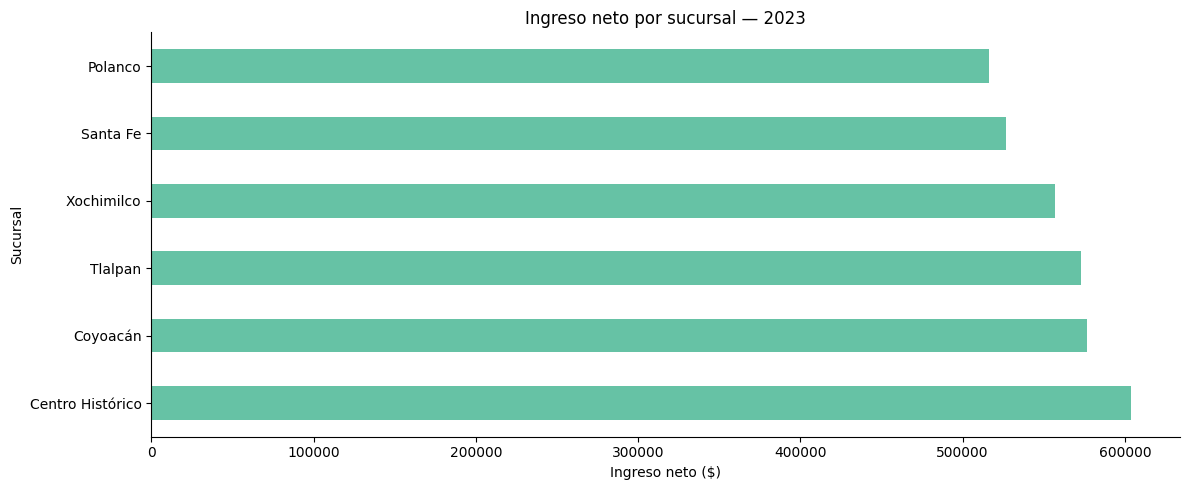

In [ ]:
# Ingreso neto total agrupado por sucursal, ordenado de mayor a menor
ingresos_sucursal = df.groupby('SUCURSAL')['INGRESO_NETO'].sum().sort_values(ascending=False)

mejor = ingresos_sucursal.index[0]
peor  = ingresos_sucursal.index[-1]
diferencia = ingresos_sucursal.iloc[0] - ingresos_sucursal.iloc[-1]

print(f'Sucursal con más ingresos:  {mejor}  (${ingresos_sucursal.iloc[0]:,.0f})')
print(f'Sucursal con menos ingresos: {peor}  (${ingresos_sucursal.iloc[-1]:,.0f})')
print(f'Diferencia: ${diferencia:,.0f}')

# Gráfica de barras horizontales ordenadas
ingresos_sucursal.plot(kind='barh')
plt.title('Ingreso neto por sucursal — 2023')
plt.xlabel('Ingreso neto ($)')
plt.ylabel('Sucursal')
plt.tight_layout()
plt.show()

---
## Pregunta 2 — ¿En qué meses vendemos más y en qué meses caemos?

Mes con más ventas:   mes 5  ($341,569)
Mes con menos ventas: mes 12  ($133,224)


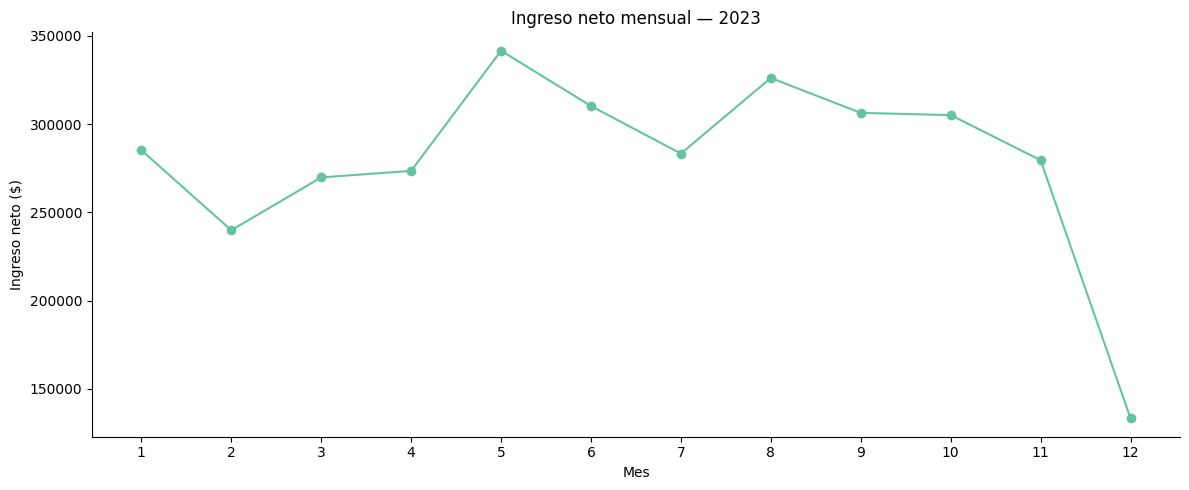

In [ ]:
# Ingreso neto mensual agrupado por número de mes
ingresos_mes = df.groupby('MES')['INGRESO_NETO'].sum()

mes_alto = ingresos_mes.idxmax()
mes_bajo = ingresos_mes.idxmin()

print(f'Mes con más ventas:   mes {mes_alto}  (${ingresos_mes[mes_alto]:,.0f})')
print(f'Mes con menos ventas: mes {mes_bajo}  (${ingresos_mes[mes_bajo]:,.0f})')

# Gráfica de línea para ver la tendencia mes a mes
ingresos_mes.plot(kind='line', marker='o')
plt.title('Ingreso neto mensual — 2023')
plt.xlabel('Mes')
plt.ylabel('Ingreso neto ($)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

---
## Pregunta 3 — ¿Qué turno es más rentable? ¿Es consistente entre zonas?

Ingreso neto por turno:
TURNO
Noche    1403106.68
Tarde     988625.18
Mañana    961878.28
Name: INGRESO_NETO, dtype: Float64

Ingreso neto por zona y turno:
TURNO       Mañana     Noche     Tarde
ZONA                                  
Centro   167354.49 254887.43 181541.34
Norte    131365.33 233986.17 151099.91
Poniente 170775.54 208165.88 148090.15
Sur      492382.92 706067.20 507893.78


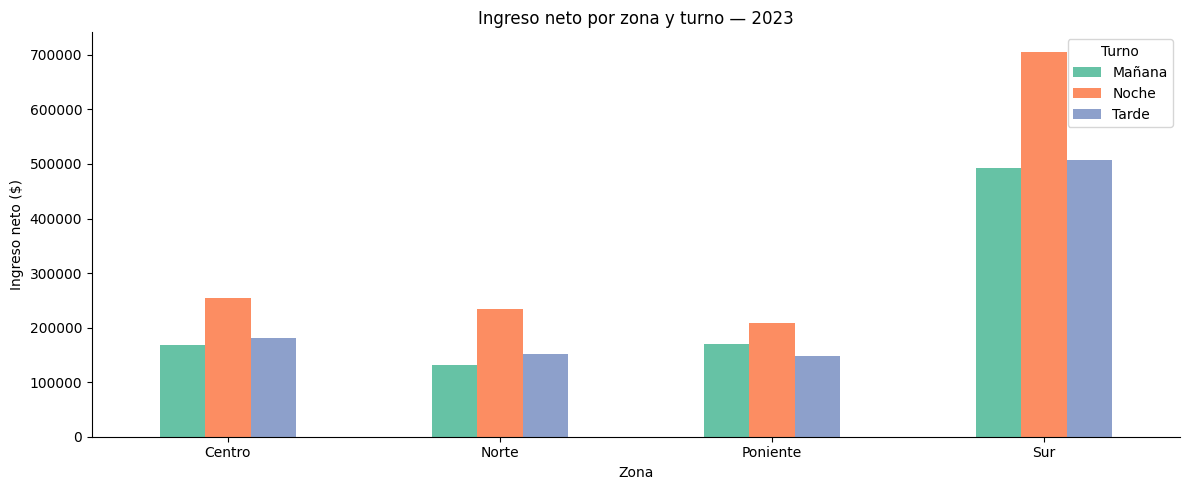

In [ ]:
# Ingreso neto por turno a nivel general
ingresos_turno = df.groupby('TURNO')['INGRESO_NETO'].sum().sort_values(ascending=False)
print('Ingreso neto por turno:')
print(ingresos_turno)

# Tabla cruzada turno × zona para ver si el patrón se repite en todas las zonas
turno_zona = df.groupby(['ZONA', 'TURNO'])['INGRESO_NETO'].sum().unstack()
print()
print('Ingreso neto por zona y turno:')
print(turno_zona)

# Barras agrupadas: cada grupo es una zona, cada barra es un turno
turno_zona.plot(kind='bar')
plt.title('Ingreso neto por zona y turno — 2023')
plt.xlabel('Zona')
plt.ylabel('Ingreso neto ($)')
plt.xticks(rotation=0)
plt.legend(title='Turno')
plt.tight_layout()
plt.show()

---
## Pregunta 4 — ¿La calificación del servicio afecta cuánto gasta el cliente?

Gasto promedio por calificación:
CALIF_REDONDA
1.00   1079.83
2.00   1200.26
3.00   1251.21
4.00   1241.25
5.00   1071.42
Name: INGRESO_NETO, dtype: Float64


/tmp/ipykernel_393/2960264085.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cal['CALIF_REDONDA'] = df_cal['CALIFICACION'].round(0)
/tmp/ipykernel_393/2960264085.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grupos, labels=etiquetas)


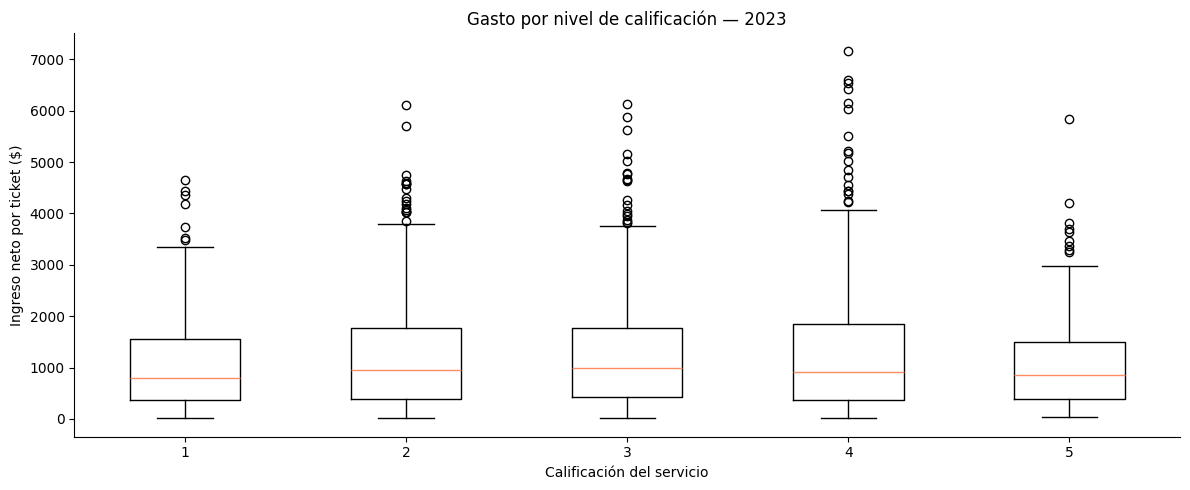

In [ ]:
# Redondear calificación al entero más cercano para agrupar (1, 2, 3, 4, 5)
df['CALIF_REDONDA'] = df['CALIFICACION'].dropna().round(0)

gasto_por_calif = df.groupby('CALIF_REDONDA')['INGRESO_NETO'].mean()
print('Gasto promedio por calificación:')
print(gasto_por_calif)

# Boxplot — muestra la distribución del gasto en cada nivel de calificación
df_cal = df.dropna(subset=['CALIFICACION'])
df_cal['CALIF_REDONDA'] = df_cal['CALIFICACION'].round(0)

grupos = [df_cal[df_cal['CALIF_REDONDA'] == c]['INGRESO_NETO'].values for c in sorted(df_cal['CALIF_REDONDA'].unique())]
etiquetas = [str(int(c)) for c in sorted(df_cal['CALIF_REDONDA'].unique())]

plt.boxplot(grupos, labels=etiquetas)
plt.title('Gasto por nivel de calificación — 2023')
plt.xlabel('Calificación del servicio')
plt.ylabel('Ingreso neto por ticket ($)')
plt.tight_layout()
plt.show()

---
## Pregunta 5 — ¿Qué categoría de producto tiene el margen más alto?

Margen por categoría = `INGRESO_NETO.sum() / INGRESO_BRUTO.sum()`

Margen por categoría:
CATEGORIA_PRODUCTO
Bebidas   80.02
Tacos     79.96
Extras    79.82
Combos    79.45
Postres   79.28
dtype: Float64


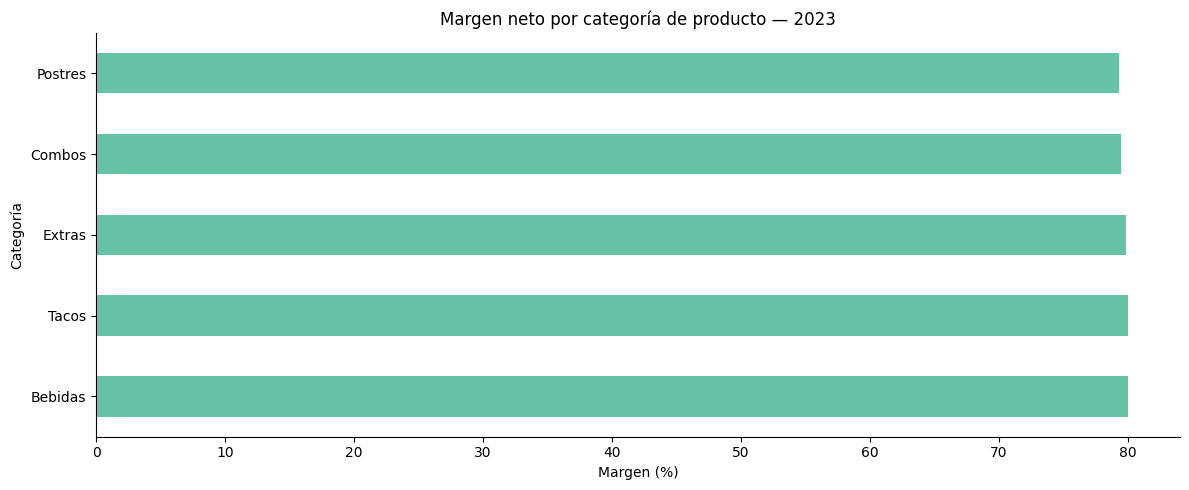

In [ ]:
# Margen = ingreso neto total / ingreso bruto total por categoría
bruto_cat = df.groupby('CATEGORIA_PRODUCTO')['INGRESO_BRUTO'].sum()
neto_cat  = df.groupby('CATEGORIA_PRODUCTO')['INGRESO_NETO'].sum()

margen_cat = (neto_cat / bruto_cat).sort_values(ascending=False)
margen_cat_pct = margen_cat * 100

print('Margen por categoría:')
print(margen_cat_pct.round(2))

# Barras horizontales ordenadas por margen
margen_cat_pct.plot(kind='barh')
plt.title('Margen neto por categoría de producto — 2023')
plt.xlabel('Margen (%)')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

---
# PARTE 3 — CONCLUSIONES EJECUTIVAS ✍️

Resumen de los hallazgos principales. Máximo 2 oraciones por punto, con los números reales obtenidos en el análisis.

In [ ]:
# Reporte ejecutivo con los números calculados en la Parte 2
turno_top = ingresos_turno.index[0]
mejor_cat = margen_cat_pct.index[0]
peor_cat  = margen_cat_pct.index[-1]

print(f"""
REPORTE EJECUTIVO — TaquerIA 2023
══════════════════════════════════════════

1. SUCURSALES
   {mejor} es la sucursal con mayor ingreso neto (${ingresos_sucursal.iloc[0]:,.0f}),
   mientras que {peor} es la de menor ingreso (${ingresos_sucursal.iloc[-1]:,.0f}).
   La diferencia entre ambas es de ${diferencia:,.0f}.

2. ESTACIONALIDAD
   El mes con más ventas fue el mes {mes_alto} (${ingresos_mes[mes_alto]:,.0f})
   y el de menor actividad fue el mes {mes_bajo} (${ingresos_mes[mes_bajo]:,.0f}).

3. TURNOS
   El turno más rentable a nivel general es {turno_top} con ${ingresos_turno.iloc[0]:,.0f} en ingreso neto.
   Ver gráfica P3 para saber si este patrón se mantiene en todas las zonas.

4. CALIFICACIÓN Y GASTO
   El gasto promedio por calificación muestra {'una tendencia positiva' if gasto_por_calif.iloc[-1] > gasto_por_calif.iloc[0] else 'poca diferencia entre niveles'}.
   Calificación más alta promedia ${gasto_por_calif.iloc[-1]:,.0f} vs ${gasto_por_calif.iloc[0]:,.0f} en la más baja.

5. MÁRGENES
   La categoría con mayor margen es {mejor_cat} ({margen_cat_pct[mejor_cat]:.1f}%)
   y la de menor margen es {peor_cat} ({margen_cat_pct[peor_cat]:.1f}%).

RECOMENDACIÓN PRINCIPAL:
   Enfocar esfuerzos en replicar el modelo de {mejor} en las sucursales de menor ingreso,
   y priorizar la categoría {mejor_cat} que tiene el mejor margen.
""")


REPORTE EJECUTIVO — TaquerIA 2023
══════════════════════════════════════════

1. SUCURSALES
   Centro Histórico es la sucursal con mayor ingreso neto ($603,783),
   mientras que Polanco es la de menor ingreso ($516,451).
   La diferencia entre ambas es de $87,332.

2. ESTACIONALIDAD
   El mes con más ventas fue el mes 5 ($341,569)
   y el de menor actividad fue el mes 12 ($133,224).

3. TURNOS
   El turno más rentable a nivel general es Noche con $1,403,107 en ingreso neto.
   Ver gráfica P3 para saber si este patrón se mantiene en todas las zonas.

4. CALIFICACIÓN Y GASTO
   El gasto promedio por calificación muestra poca diferencia entre niveles.
   Calificación más alta promedia $1,071 vs $1,080 en la más baja.

5. MÁRGENES
   La categoría con mayor margen es Bebidas (80.0%)
   y la de menor margen es Postres (79.3%).

RECOMENDACIÓN PRINCIPAL:
   Enfocar esfuerzos en replicar el modelo de Centro Histórico en las sucursales de menor ingreso,
   y priorizar la categoría Bebidas que t